<a href="https://colab.research.google.com/github/mjmousavi97/Deep-Learning/blob/master/src/CTC%20Loss%20AND%20Audio%20Data/Transferlaerning_YamNet.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install -Uqq tensorflow_io

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.6/49.6 MB 17.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.1/5.1 MB 61.6 MB/s eta 0:00:00


In [32]:
import os
import tensorflow as tf
from tensorflow import keras
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import IPython
import tensorflow_hub as hub
import tensorflow_io as tfio
from keras.layers import Dense, Dropout, Input
from keras.models import Model
from keras.optimizers import Adam
from keras.losses import BinaryCrossentropy

In [3]:
import tensorflow as tf
import tensorflow_io as tfio

print(tf.__version__)
print(tfio.__version__)

2.20.0
0.37.1


In [4]:
#Ues YamNet model from tensorflow Hub
yamnet_model_handle = 'https://tfhub.dev/google/yamnet/1'
yamnet_model = hub.load(yamnet_model_handle)


In [5]:
testing_wav_file_name = tf.keras.utils.get_file(
    'miaow_16k.wav',
    'https://storage.googleapis.com/audioset/miaow_16k.wav',
    cache_dir='./',
    cache_subdir='test_data'
)

print(testing_wav_file_name)

215546/215546 ━━━━━━━━━━━━━━━━━━━━ 1s 3us/step
./test_data/miaow_16k.wav


In [6]:
file_content = tf.io.read_file(testing_wav_file_name)
audio, sample_rate = tf.audio.decode_wav(contents=file_content)

print(f"Audio shape: {audio.shape}")
print(f"Sample rate: {sample_rate}")

Audio shape: (107698, 1)
Sample rate: 16000


In [7]:
IPython.display.Audio(tf.squeeze(audio), rate=sample_rate.numpy())

In [8]:
@tf.function
def read_and_load_wave(file_path):

    binary_file = tf.io.read_file(file_path)
    waveform, sample_rate = tf.audio.decode_wav(binary_file)

    waveform = tf.squeeze(waveform, axis=-1)
    sample_rate = tf.cast(sample_rate, dtype=tf.int64)
    # waveform = tfio.audio.resample(waveform, sample_rate, 16000)

    return waveform, sample_rate

In [9]:
waveform, sample_rate = read_and_load_wave(testing_wav_file_name)
IPython.display.Audio(waveform.numpy(), rate=sample_rate.numpy())

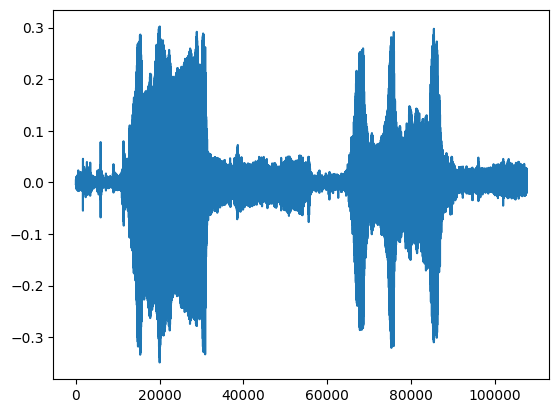

In [10]:
plt.plot(waveform)

In [11]:
# Test the yamnet model
scores, embeddings, spectrogram = yamnet_model(waveform)

print(f"scores: {scores.shape}")
print(f"embeddings: {embeddings.shape}")
print(f"spectrogram: {spectrogram.shape}")

scores: (13, 521)
embeddings: (13, 1024)
spectrogram: (672, 64)


In [12]:
cvs_model_name = yamnet_model.class_map_path().numpy().decode('utf-8')
print(cvs_model_name)

csv_model_file = pd.read_csv(cvs_model_name)
csv_model_file.head(10)

/tmp/tfhub_modules/9616fd04ec2360621642ef9455b84f4b668e219e/assets/yamnet_class_map.csv


,index,mid,display_name
0,0,/m/09x0r,Speech
1,1,/m/0ytgt,"Child speech, kid speaking"
2,2,/m/01h8n0,Conversation
3,3,/m/02qldy,"Narration, monologue"
4,4,/m/0261r1,Babbling
5,5,/m/0brhx,Speech synthesizer
6,6,/m/07p6fty,Shout
7,7,/m/07q4ntr,Bellow
8,8,/m/07rwj3x,Whoop
9,9,/m/07sr1lc,Yell


In [13]:
class_names = list(csv_model_file['display_name'].unique())
print(class_names)
print(f"Number of classes: {len(class_names)}")

['Speech', 'Child speech, kid speaking', 'Conversation', 'Narration, monologue', 'Babbling', 'Speech synthesizer', 'Shout', 'Bellow', 'Whoop', 'Yell', 'Children shouting', 'Screaming', 'Whispering', 'Laughter', 'Baby laughter', 'Giggle', 'Snicker', 'Belly laugh', 'Chuckle, chortle', 'Crying, sobbing', 'Baby cry, infant cry', 'Whimper', 'Wail, moan', 'Sigh', 'Singing', 'Choir', 'Yodeling', 'Chant', 'Mantra', 'Child singing', 'Synthetic singing', 'Rapping', 'Humming', 'Groan', 'Grunt', 'Whistling', 'Breathing', 'Wheeze', 'Snoring', 'Gasp', 'Pant', 'Snort', 'Cough', 'Throat clearing', 'Sneeze', 'Sniff', 'Run', 'Shuffle', 'Walk, footsteps', 'Chewing, mastication', 'Biting', 'Gargling', 'Stomach rumble', 'Burping, eructation', 'Hiccup', 'Fart', 'Hands', 'Finger snapping', 'Clapping', 'Heart sounds, heartbeat', 'Heart murmur', 'Cheering', 'Applause', 'Chatter', 'Crowd', 'Hubbub, speech noise, speech babble', 'Children playing', 'Animal', 'Domestic animals, pets', 'Dog', 'Bark', 'Yip', 'Howl'

In [14]:
# Get the class names from the YAMNet model

# Calculate the mean of the scores
mean_scores = tf.reduce_mean(scores, axis=0)

# Find the indices of the top scoring classes
top_indices = tf.argsort(mean_scores, direction='DESCENDING')

print("Mean scores and their corresponding labels:")
for i in range(5):  # Print top 5 classes
    index = top_indices[i]
    print(f"  {class_names[index]}: {mean_scores[index].numpy():.4f}")

Mean scores and their corresponding labels:
  Animal: 0.7132
  Domestic animals, pets: 0.5123
  Cat: 0.4236
  Meow: 0.2008
  Fowl: 0.1045


In [15]:
# To download the dataset(ESC-50 dataset)
dataset_path = tf.keras.utils.get_file(
    origin='https://github.com/karoldvl/ESC-50/archive/master.zip',
    fname='esc50.zip',
    extract=True,
    cache_dir='.', cache_subdir='esc5_dataset')


645693440/Unknown 42s 0us/step

In [16]:
esc_csv_path = "/content/esc5_dataset/esc50_extracted/ESC-50-master/meta/esc50.csv"

esc_csv_file = pd.read_csv(esc_csv_path)
esc_csv_file.head(10)

,filename,fold,target,category,esc10,src_file,take
0,1-100032-A-0.wav,1,0,dog,True,100032,A
1,1-100038-A-14.wav,1,14,chirping_birds,False,100038,A
2,1-100210-A-36.wav,1,36,vacuum_cleaner,False,100210,A
3,1-100210-B-36.wav,1,36,vacuum_cleaner,False,100210,B
4,1-101296-A-19.wav,1,19,thunderstorm,False,101296,A
5,1-101296-B-19.wav,1,19,thunderstorm,False,101296,B
6,1-101336-A-30.wav,1,30,door_wood_knock,False,101336,A
7,1-101404-A-34.wav,1,34,can_opening,False,101404,A
8,1-103298-A-9.wav,1,9,crow,False,103298,A
9,1-103995-A-30.wav,1,30,door_wood_knock,False,103995,A


In [17]:
esc_csv_file.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   filename  2000 non-null   object
 1   fold      2000 non-null   int64 
 2   target    2000 non-null   int64 
 3   category  2000 non-null   object
 4   esc10     2000 non-null   bool  
 5   src_file  2000 non-null   int64 
 6   take      2000 non-null   object
dtypes: bool(1), int64(3), object(3)
memory usage: 95.8+ KB


In [18]:
# filter on sec csv file(only select audio of cat and dog)
filtered_esc_csv_file = esc_csv_file[esc_csv_file['category'].isin(['cat', 'dog'])]

map_class_to_id = {'cat': 0, 'dog': 1}
filtered_esc_csv_file['target'] = filtered_esc_csv_file['category'].map(lambda x: map_class_to_id.get(x, None))

filtered_esc_csv_file.head(10)

/tmp/ipykernel_733/2744957359.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  filtered_esc_csv_file['target'] = filtered_esc_csv_file['category'].map(lambda x: map_class_to_id.get(x, None))


,filename,fold,target,category,esc10,src_file,take
0,1-100032-A-0.wav,1,1,dog,True,100032,A
14,1-110389-A-0.wav,1,1,dog,True,110389,A
157,1-30226-A-0.wav,1,1,dog,True,30226,A
158,1-30344-A-0.wav,1,1,dog,True,30344,A
170,1-32318-A-0.wav,1,1,dog,True,32318,A
175,1-34094-A-5.wav,1,0,cat,False,34094,A
176,1-34094-B-5.wav,1,0,cat,False,34094,B
229,1-47819-A-5.wav,1,0,cat,False,47819,A
230,1-47819-B-5.wav,1,0,cat,False,47819,B
231,1-47819-C-5.wav,1,0,cat,False,47819,C


In [19]:
filtered_esc_csv_file.info()

<class 'pandas.core.frame.DataFrame'>
Index: 80 entries, 0 to 1999
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   filename  80 non-null     object
 1   fold      80 non-null     int64 
 2   target    80 non-null     int64 
 3   category  80 non-null     object
 4   esc10     80 non-null     bool  
 5   src_file  80 non-null     int64 
 6   take      80 non-null     object
dtypes: bool(1), int64(3), object(3)
memory usage: 4.5+ KB


In [20]:
audio_sub_dir = "/content/esc5_dataset/esc50_extracted/ESC-50-master/audio"

filtered_esc_csv_file['file_path'] = filtered_esc_csv_file['filename'].apply(lambda x: os.path.join(audio_sub_dir, x))
filtered_esc_csv_file.head(10)

/tmp/ipykernel_733/664592870.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  filtered_esc_csv_file['file_path'] = filtered_esc_csv_file['filename'].apply(lambda x: os.path.join(audio_sub_dir, x))


,filename,fold,target,category,esc10,src_file,take,file_path
0,1-100032-A-0.wav,1,1,dog,True,100032,A,/content/esc5_dataset/esc50_extracted/ESC-50-m...
14,1-110389-A-0.wav,1,1,dog,True,110389,A,/content/esc5_dataset/esc50_extracted/ESC-50-m...
157,1-30226-A-0.wav,1,1,dog,True,30226,A,/content/esc5_dataset/esc50_extracted/ESC-50-m...
158,1-30344-A-0.wav,1,1,dog,True,30344,A,/content/esc5_dataset/esc50_extracted/ESC-50-m...
170,1-32318-A-0.wav,1,1,dog,True,32318,A,/content/esc5_dataset/esc50_extracted/ESC-50-m...
175,1-34094-A-5.wav,1,0,cat,False,34094,A,/content/esc5_dataset/esc50_extracted/ESC-50-m...
176,1-34094-B-5.wav,1,0,cat,False,34094,B,/content/esc5_dataset/esc50_extracted/ESC-50-m...
229,1-47819-A-5.wav,1,0,cat,False,47819,A,/content/esc5_dataset/esc50_extracted/ESC-50-m...
230,1-47819-B-5.wav,1,0,cat,False,47819,B,/content/esc5_dataset/esc50_extracted/ESC-50-m...
231,1-47819-C-5.wav,1,0,cat,False,47819,C,/content/esc5_dataset/esc50_extracted/ESC-50-m...


In [21]:
filtered_esc_csv_file.reset_index(drop=True, inplace=True)
filtered_esc_csv_file.head(10)

,filename,fold,target,category,esc10,src_file,take,file_path
0,1-100032-A-0.wav,1,1,dog,True,100032,A,/content/esc5_dataset/esc50_extracted/ESC-50-m...
1,1-110389-A-0.wav,1,1,dog,True,110389,A,/content/esc5_dataset/esc50_extracted/ESC-50-m...
2,1-30226-A-0.wav,1,1,dog,True,30226,A,/content/esc5_dataset/esc50_extracted/ESC-50-m...
3,1-30344-A-0.wav,1,1,dog,True,30344,A,/content/esc5_dataset/esc50_extracted/ESC-50-m...
4,1-32318-A-0.wav,1,1,dog,True,32318,A,/content/esc5_dataset/esc50_extracted/ESC-50-m...
5,1-34094-A-5.wav,1,0,cat,False,34094,A,/content/esc5_dataset/esc50_extracted/ESC-50-m...
6,1-34094-B-5.wav,1,0,cat,False,34094,B,/content/esc5_dataset/esc50_extracted/ESC-50-m...
7,1-47819-A-5.wav,1,0,cat,False,47819,A,/content/esc5_dataset/esc50_extracted/ESC-50-m...
8,1-47819-B-5.wav,1,0,cat,False,47819,B,/content/esc5_dataset/esc50_extracted/ESC-50-m...
9,1-47819-C-5.wav,1,0,cat,False,47819,C,/content/esc5_dataset/esc50_extracted/ESC-50-m...


In [22]:
filtered_esc_csv_file.tail(10)

,filename,fold,target,category,esc10,src_file,take,file_path
70,5-208030-A-0.wav,5,1,dog,True,208030,A,/content/esc5_dataset/esc50_extracted/ESC-50-m...
71,5-212454-A-0.wav,5,1,dog,True,212454,A,/content/esc5_dataset/esc50_extracted/ESC-50-m...
72,5-213855-A-0.wav,5,1,dog,True,213855,A,/content/esc5_dataset/esc50_extracted/ESC-50-m...
73,5-214759-A-5.wav,5,0,cat,False,214759,A,/content/esc5_dataset/esc50_extracted/ESC-50-m...
74,5-214759-B-5.wav,5,0,cat,False,214759,B,/content/esc5_dataset/esc50_extracted/ESC-50-m...
75,5-217158-A-0.wav,5,1,dog,True,217158,A,/content/esc5_dataset/esc50_extracted/ESC-50-m...
76,5-231762-A-0.wav,5,1,dog,True,231762,A,/content/esc5_dataset/esc50_extracted/ESC-50-m...
77,5-256452-A-5.wav,5,0,cat,False,256452,A,/content/esc5_dataset/esc50_extracted/ESC-50-m...
78,5-259169-A-5.wav,5,0,cat,False,259169,A,/content/esc5_dataset/esc50_extracted/ESC-50-m...
79,5-9032-A-0.wav,5,1,dog,True,9032,A,/content/esc5_dataset/esc50_extracted/ESC-50-m...


In [28]:
main_ds = tf.data.Dataset.from_tensor_slices((filtered_esc_csv_file['file_path'], filtered_esc_csv_file['target'], filtered_esc_csv_file['fold']))
main_ds.element_spec

for data in main_ds.take(10):
    print(f"{data[0].numpy().decode('utf-8')}, {data[1].numpy()}, {data[2].numpy()}")

/content/esc5_dataset/esc50_extracted/ESC-50-master/audio/1-100032-A-0.wav, 1, 1
/content/esc5_dataset/esc50_extracted/ESC-50-master/audio/1-110389-A-0.wav, 1, 1
/content/esc5_dataset/esc50_extracted/ESC-50-master/audio/1-30226-A-0.wav, 1, 1
/content/esc5_dataset/esc50_extracted/ESC-50-master/audio/1-30344-A-0.wav, 1, 1
/content/esc5_dataset/esc50_extracted/ESC-50-master/audio/1-32318-A-0.wav, 1, 1
/content/esc5_dataset/esc50_extracted/ESC-50-master/audio/1-34094-A-5.wav, 0, 1
/content/esc5_dataset/esc50_extracted/ESC-50-master/audio/1-34094-B-5.wav, 0, 1
/content/esc5_dataset/esc50_extracted/ESC-50-master/audio/1-47819-A-5.wav, 0, 1
/content/esc5_dataset/esc50_extracted/ESC-50-master/audio/1-47819-B-5.wav, 0, 1
/content/esc5_dataset/esc50_extracted/ESC-50-master/audio/1-47819-C-5.wav, 0, 1


In [31]:
main_ds.element_spec

(TensorSpec(shape=(), dtype=tf.string, name=None),
 TensorSpec(shape=(), dtype=tf.int64, name=None),
 TensorSpec(shape=(), dtype=tf.int64, name=None))

In [33]:
# Embedd audio files
main_ds = main_ds.map(lambda x, y, z: (read_and_load_wave(x)[0], y, z))
main_ds.element_spec

(TensorSpec(shape=(None,), dtype=tf.float32, name=None),
 TensorSpec(shape=(), dtype=tf.int64, name=None),
 TensorSpec(shape=(), dtype=tf.int64, name=None))

In [37]:
for data in main_ds.take(5):
    print(f"{data[0].shape}, {data[1].numpy()}, {data[2].numpy()}")

IPython.display.Audio(data[0].numpy(), rate=16000)

(220500,), 1, 1
(220500,), 1, 1
(220500,), 1, 1
(220500,), 1, 1
(220500,), 1, 1


In [40]:
main_ds = main_ds.map(lambda x, y, z: (tf.reduce_mean(yamnet_model(x)[1], axis=0), y, z))
main_ds.element_spec

for data in main_ds.take(5):
    print(f"{data[0].shape}, {data[1].numpy()}, {data[2].numpy()}")

(1024,), 1, 1
(1024,), 1, 1
(1024,), 1, 1
(1024,), 1, 1
(1024,), 1, 1


In [42]:
# Create a binary model to classify dog vs. cat
input = Input(shape=(1024, ))
x = Dense(64, activation='relu')(input)
x = Dropout(0.5)(x)

x = Dense(64, activation='relu')(x)
x = Dropout(0.5)(x)

output = Dense(1, activation='sigmoid')(x)

model = Model(input, output)

In [43]:
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │        65,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 69,825 (272.75 KB)

 Trainable params: 69,825 (272.75 KB)

 Non-trainable params: 0 (0.00 B)